# Predict in-season FPL performance based on lagged player performance data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
import shap
from catboost import EFeaturesSelectionAlgorithm, Pool
from training.load_training_data import (
    load_historic_player_fixture_data,
)
from training.config import MAX_HORIZON, NUMERIC_FEATURES, ROLLING_WINDOWS, RANDOM_STATE
from training.transformations import create_fixture_horizon_df, create_trended_calculations
from prediction.artifacts.io import save_trained_catboost_model
from prediction.artifacts.io import MINUTES_ARTIFACT_PATH

MAX_FEATURES = 20
TARGET_COLUMN = 'minutes'

Matplotlib is building the font cache; this may take a moment.


# Train and evaluate on 2022/23 and 2023/24 seasons

In [2]:
TRAINING_SEASONS = ["2022-23", "2023-24"]

fixture_history_df = pd.concat(
    [
        load_historic_player_fixture_data(season)
        .rename(columns={"GW": "target_gw"})
        .assign(season=season)
        for season in TRAINING_SEASONS
    ],
    ignore_index=True,
    sort=False,
)

fixture_history_df = fixture_history_df.sort_values(
    ["player_id", "season", "target_gw", "fixture_id"]
).reset_index(drop=True)

print(fixture_history_df.groupby("season").size())
fixture_history_df.head()

season
2022-23    26505
2023-24    29725
dtype: int64


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,player_id,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,target_gw,season
0,Cédric Alves Soares,DEF,Arsenal,2.4,0,0,0,0,0.0,1,...,0.0,0,0,0,0,45,False,0,1,2022-23
1,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0,-5169,1361,6530,44,True,0,2,2022-23
2,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0,-4337,879,5216,44,False,0,3,2022-23
3,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0,-2988,577,3565,43,True,0,4,2022-23
4,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0,-1611,405,2016,43,True,0,5,2022-23


# Feature engineering

In [3]:
CATEGORICAL_COLUMNS = ["position",
                       "target_gw",
                       "current_gw",
                       "horizon",
    ]

In [4]:
calculated_features_df = create_trended_calculations(
    fixture_history_df,
    rolling_windows= ROLLING_WINDOWS,
    numeric_features=NUMERIC_FEATURES
)

fixture_history_df = pd.concat(
    [fixture_history_df, calculated_features_df],
    axis=1,
)

calculated_columns = calculated_features_df.columns.tolist()

In [5]:
fixture_history_df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,player_id,...,calc_bps_stdev_last_12_fixtures,calc_influence_stdev_last_12_fixtures,calc_creativity_stdev_last_12_fixtures,calc_threat_stdev_last_12_fixtures,calc_ict_index_stdev_last_12_fixtures,calc_starts_stdev_last_12_fixtures,calc_expected_goals_stdev_last_12_fixtures,calc_expected_assists_stdev_last_12_fixtures,calc_expected_goal_involvements_stdev_last_12_fixtures,calc_expected_goals_conceded_stdev_last_12_fixtures
0,Cédric Alves Soares,DEF,Arsenal,2.4,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Adding in time horizon data

We want our model to make predictions up to x gameweeks in advance. For each target fixture, `fixture_history_with_horizons_df` contains one row per horizon from 0 to MAX_HORIZON. Rolling features contain only information available through `current_gw`.

If horizon = 0 then prediction is for the coming gameweek using the most up to date data 

### Definitions
- `target_gw`: the gameweek in which the target fixture occurs.
- `current_gw`: the gameweek at whose beginning the forecast is generated; its results are included in the rolling history.
- `horizon = target_gw - current_gw`.

In [6]:
fixture_history_with_horizons_df = create_fixture_horizon_df(
    fixture_history_df = fixture_history_df,
    max_horizon = MAX_HORIZON,
    calculated_columns = calculated_columns,
    target_column = TARGET_COLUMN
)

# MVP model

In [7]:
model_features = CATEGORICAL_COLUMNS + calculated_columns

In [8]:
# Split chronologically by complete season-gameweeks. All horizon versions of
# a target fixture remain together on one side of the split.
validation_fraction = 0.2
season_fixture_gameweeks = (
    fixture_history_with_horizons_df[["season", "target_gw"]]
    .drop_duplicates()
    .sort_values(["season", "target_gw"])
)
validation_fixture_gameweek_count = max(1, int(np.ceil(
    len(season_fixture_gameweeks) * validation_fraction
)))
validation_fixture_gameweeks = pd.MultiIndex.from_frame(
    season_fixture_gameweeks.tail(validation_fixture_gameweek_count)
)
row_fixture_gameweeks = pd.MultiIndex.from_frame(
    fixture_history_with_horizons_df[["season", "target_gw"]]
)
validation_mask = row_fixture_gameweeks.isin(validation_fixture_gameweeks)
train_index = fixture_history_with_horizons_df.index[~validation_mask]
valid_index = fixture_history_with_horizons_df.index[validation_mask]

X_train = fixture_history_with_horizons_df.loc[train_index, model_features].copy()
y_train = fixture_history_with_horizons_df.loc[train_index, TARGET_COLUMN].copy()

X_valid = fixture_history_with_horizons_df.loc[valid_index, model_features].copy()
y_valid = fixture_history_with_horizons_df.loc[valid_index, TARGET_COLUMN].copy()
for frame in (X_train, X_valid):
    frame[CATEGORICAL_COLUMNS] = (
        frame[CATEGORICAL_COLUMNS].fillna("__MISSING__").astype(str)
    )

print(f"Train players: {len(X_train):,}; validation players: {len(X_valid):,}")


Train players: 424,119; validation players: 154,116


## Dummy model

In [9]:
from sklearn.dummy import DummyRegressor

models = {}
validation_predictions = {}

dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train[["horizon"]], y_train)
models["Dummy"] = dummy_model
validation_predictions["Dummy"] = dummy_model.predict(X_valid[["horizon"]])

## Unweighted

In [10]:
def fit_catboost(sample_weight=None):
    fitted_model = CatBoostRegressor(
        iterations=163,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    fitted_model.fit(
        X_train,
        y_train,
        cat_features=CATEGORICAL_COLUMNS,
        sample_weight=sample_weight,
    )
    return fitted_model

unweighted_model = fit_catboost()
models["Unweighted"] = unweighted_model
validation_predictions["Unweighted"] = unweighted_model.predict(X_valid)

## Unweighted model with optimised feature list

### Without catgegorical columns enforced to be selected

In [11]:
feature_selection_model = CatBoostRegressor(
    iterations=163,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)

train_pool = Pool(
    X_train,
    y_train,
    cat_features=CATEGORICAL_COLUMNS,
)
valid_pool = Pool(
    X_valid,
    y_valid,
    cat_features=CATEGORICAL_COLUMNS,
)
MAX_FEATURES = 20

target_feature_count = min(MAX_FEATURES, len(model_features))
features_to_remove = len(model_features) - target_feature_count

if features_to_remove == 0:
    selected_features = model_features.copy()
else:
    selection = feature_selection_model.select_features(
        train_pool,
        eval_set=valid_pool,
        features_for_select=model_features,
        num_features_to_select=target_feature_count,
        steps=min(10, features_to_remove),
        algorithm=(
            EFeaturesSelectionAlgorithm
            .RecursiveByLossFunctionChange
        ),
        train_final_model=False,
        verbose=False,
    )

    selected_features = selection["selected_features_names"]

selected_categorical_columns = [
    column for column in CATEGORICAL_COLUMNS if column in selected_features
]
unweighted_selected_model = CatBoostRegressor(
    iterations=163,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
unweighted_selected_model.fit(
    X_train[selected_features],
    y_train,
    cat_features=selected_categorical_columns,
)
models["Unweighted - top 20"] = unweighted_selected_model
validation_predictions["Unweighted - top 20"] = (
    unweighted_selected_model.predict(X_valid[selected_features])
)
print(f"Selected features: {selected_features}")

Step #1 out of 10



bestTest = 26.72534804
bestIteration = 162



Feature #214 eliminated
Feature #163 eliminated
Feature #107 eliminated
Feature #207 eliminated
Feature #113 eliminated
Feature #138 eliminated
Feature #232 eliminated
Feature #230 eliminated
Feature #144 eliminated
Feature #153 eliminated
Feature #222 eliminated
Feature #84 eliminated
Feature #141 eliminated
Feature #194 eliminated
Feature #221 eliminated
Feature #131 eliminated
Feature #23 eliminated
Feature #171 eliminated
Feature #122 eliminated
Feature #57 eliminated
Feature #7 eliminated
Feature #83 eliminated
Feature #167 eliminated
Feature #6 eliminated
Feature #61 eliminated
Feature #137 eliminated
Feature #185 eliminated
Feature #199 eliminated
Feature #42 eliminated
Feature #30 eliminated
Feature #56 eliminated
Feature #2 eliminated
Feature #8 eliminated
Feature #9 eliminated
Feature #10 eliminated
Feature #11 eliminated
Feature #13 eliminated
Feature #14 eliminated
Feature #15 eliminated
Feature #16 eliminated
Feature #22 eliminated
Feature #25 eliminated
Feature #26 elimin


bestTest = 26.72836116
bestIteration = 162



Feature #168 eliminated
Feature #176 eliminated
Feature #165 eliminated
Feature #209 eliminated
Feature #186 eliminated
Feature #182 eliminated
Feature #149 eliminated
Feature #78 eliminated
Feature #119 eliminated
Feature #139 eliminated
Feature #68 eliminated
Feature #79 eliminated
Feature #103 eliminated
Feature #66 eliminated
Feature #76 eliminated
Feature #92 eliminated
Feature #62 eliminated
Feature #130 eliminated
Feature #100 eliminated
Feature #125 eliminated
Feature #75 eliminated
Feature #91 eliminated
Feature #115 eliminated
Feature #77 eliminated
Feature #58 eliminated
Feature #231 eliminated
Feature #12 eliminated
Feature #24 eliminated
Feature #36 eliminated
Feature #37 eliminated
Feature #38 eliminated
Feature #39 eliminated
Feature #40 eliminated
Feature #41 eliminated
Feature #43 eliminated
Feature #44 eliminated
Feature #45 eliminated
Feature #46 eliminated
Feature #47 eliminated
Feature #48 eliminated
Step #3 out of 10


...


bestTest = 26.71583858
bestIteration = 161

Shrink model to first 162 iterations.


Feature #178 eliminated
Feature #18 eliminated
Feature #223 eliminated
Feature #65 eliminated
Feature #156 eliminated
Feature #4 eliminated
Feature #142 eliminated
Step #10 out of 10



bestTest = 26.7304875
bestIteration = 162



Feature #133 eliminated
Feature #210 eliminated
Feature #21 eliminated
Feature #226 eliminated
Feature #179 eliminated
Feature #64 eliminated


Selected features: ['horizon', 'calc_minutes_mean_last_1_fixtures', 'calc_bps_mean_last_1_fixtures', 'calc_creativity_mean_last_1_fixtures', 'calc_minutes_mean_last_3_fixtures', 'calc_minutes_mean_last_6_fixtures', 'calc_influence_mean_last_6_fixtures', 'calc_minutes_stdev_last_6_fixtures', 'calc_minutes_mean_last_9_fixtures', 'calc_bps_mean_last_9_fixtures', 'calc_minutes_stdev_last_9_fixtures', 'calc_total_points_mean_last_12_fixtures', 'calc_minutes_mean_last_12_fixtures', 'calc_bps_mean_last_12_fixtures', 'calc_influence_mean_last_12_fixtures', 'calc_creativity_mean_last_12_fixtures', 'calc_ict_index_mean_last_12_fixtures', 'calc_minutes_stdev_last_12_fixtures', 'calc_bps_stdev_last_12_fixtures', 'calc_influence_stdev_last_12_fixtures']


### With categorical columns enforced selection

In [12]:
# Keep every categorical feature and select the remaining features up to MAX_FEATURES.
target_calculated_feature_count = min(
    max(0, MAX_FEATURES - len(CATEGORICAL_COLUMNS)),
    len(calculated_columns),
)
calculated_features_to_remove = (
    len(calculated_columns) - target_calculated_feature_count
)

if calculated_features_to_remove == 0:
    selected_calculated_features = calculated_columns.copy()
else:
    enforced_selection_model = CatBoostRegressor(
        iterations=163,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    enforced_selection = enforced_selection_model.select_features(
        train_pool,
        eval_set=valid_pool,
        features_for_select=calculated_columns,
        num_features_to_select=target_calculated_feature_count,
        steps=min(10, calculated_features_to_remove),
        algorithm=(
            EFeaturesSelectionAlgorithm
            .RecursiveByLossFunctionChange
        ),
        train_final_model=False,
        verbose=False,
    )
    selected_calculated_features = [
        column
        for column in calculated_columns
        if column in enforced_selection["selected_features_names"]
    ]

enforced_selected_features = (
    CATEGORICAL_COLUMNS + selected_calculated_features
)
unweighted_enforced_model = CatBoostRegressor(
    iterations=163,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
unweighted_enforced_model.fit(
    X_train[enforced_selected_features],
    y_train,
    cat_features=CATEGORICAL_COLUMNS,
)
models["Unweighted - top 20 (categoricals enforced)"] = (
    unweighted_enforced_model
)
validation_predictions[
    "Unweighted - top 20 (categoricals enforced)"
] = unweighted_enforced_model.predict(
    X_valid[enforced_selected_features]
)
print(f"Selected features: {enforced_selected_features}")

Step #1 out of 10



bestTest = 26.72534804
bestIteration = 162



Feature #214 eliminated
Feature #163 eliminated
Feature #107 eliminated
Feature #207 eliminated
Feature #113 eliminated
Feature #138 eliminated
Feature #232 eliminated
Feature #230 eliminated
Feature #144 eliminated
Feature #153 eliminated
Feature #222 eliminated
Feature #84 eliminated
Feature #141 eliminated
Feature #194 eliminated
Feature #221 eliminated
Feature #131 eliminated
Feature #23 eliminated
Feature #171 eliminated
Feature #122 eliminated
Feature #57 eliminated
Feature #7 eliminated
Feature #83 eliminated
Feature #167 eliminated
Feature #6 eliminated
Feature #61 eliminated
Feature #137 eliminated
Feature #185 eliminated
Feature #199 eliminated
Feature #42 eliminated
Feature #30 eliminated
Feature #56 eliminated
Feature #8 eliminated
Feature #9 eliminated
Feature #10 eliminated
Feature #11 eliminated
Feature #13 eliminated
Feature #14 eliminated
Feature #15 eliminated
Feature #16 eliminated
Feature #22 eliminated
Feature #25 eliminated
Feature #26 eliminated
Feature #27 elimi


bestTest = 26.71102392
bestIteration = 162



Feature #190 eliminated
Feature #130 eliminated
Feature #79 eliminated
Feature #162 eliminated
Feature #103 eliminated
Feature #176 eliminated
Feature #114 eliminated
Feature #112 eliminated
Feature #119 eliminated
Feature #116 eliminated
Feature #12 eliminated
Feature #69 eliminated
Feature #170 eliminated
Feature #126 eliminated
Feature #77 eliminated
Feature #172 eliminated
Feature #54 eliminated
Feature #165 eliminated
Feature #160 eliminated
Feature #123 eliminated
Feature #94 eliminated
Feature #173 eliminated
Feature #53 eliminated
Feature #149 eliminated
Feature #38 eliminated
Feature #43 eliminated
Feature #44 eliminated
Feature #45 eliminated
Feature #46 eliminated
Feature #47 eliminated
Feature #48 eliminated
Feature #49 eliminated
Feature #52 eliminated
Feature #55 eliminated
Feature #58 eliminated
Feature #60 eliminated
Feature #73 eliminated
Feature #75 eliminated
Feature #76 eliminated
Feature #78 eliminated
Feature #80 eliminated
Step #3 out of 10


...


bestTest = 26.71391203
bestIteration = 162



Feature #21 eliminated
Feature #210 eliminated
Feature #64 eliminated
Feature #74 eliminated
Feature #4 eliminated
Feature #166 eliminated
Step #10 out of 10



bestTest = 26.71038563
bestIteration = 162



Feature #226 eliminated
Feature #19 eliminated
Feature #120 eliminated
Feature #110 eliminated
Feature #143 eliminated


Selected features: ['position', 'target_gw', 'current_gw', 'horizon', 'calc_minutes_mean_last_1_fixtures', 'calc_bps_mean_last_1_fixtures', 'calc_influence_mean_last_1_fixtures', 'calc_minutes_mean_last_3_fixtures', 'calc_minutes_mean_last_6_fixtures', 'calc_influence_mean_last_9_fixtures', 'calc_total_points_mean_last_12_fixtures', 'calc_minutes_mean_last_12_fixtures', 'calc_bps_mean_last_12_fixtures', 'calc_influence_mean_last_12_fixtures', 'calc_creativity_mean_last_12_fixtures', 'calc_ict_index_mean_last_12_fixtures', 'calc_total_points_stdev_last_12_fixtures', 'calc_minutes_stdev_last_12_fixtures', 'calc_bps_stdev_last_12_fixtures', 'calc_influence_stdev_last_12_fixtures']


# Comparison table
## All validation points

In [13]:
def evaluate_predictions(predictions):
    evaluation = pd.DataFrame({
        "season": fixture_history_with_horizons_df.loc[y_valid.index, "season"].to_numpy(),
        "target_gw": fixture_history_with_horizons_df.loc[y_valid.index, "target_gw"].to_numpy(),
        "horizon": fixture_history_with_horizons_df.loc[y_valid.index, "horizon"].to_numpy(),
        "actual": y_valid.to_numpy(),
        "predicted": predictions,
    })
    actual_appearance = evaluation["actual"].gt(0)
    predicted_appearance = evaluation["predicted"].gt(0)

    return {
        "MAE": mean_absolute_error(evaluation["actual"], evaluation["predicted"]),
        "RMSE": root_mean_squared_error(evaluation["actual"], evaluation["predicted"]),
        "R2": r2_score(evaluation["actual"], evaluation["predicted"]),
        "appearance_hit_rate": (
            predicted_appearance.eq(actual_appearance).mean()
        ),
        **{
            f"absolute_error_p{percentile}": evaluation["actual"]
            .sub(evaluation["predicted"])
            .abs()
            .quantile(percentile / 100)
            for percentile in (25, 50, 75, 90)
        },
    }

comparison_table = pd.DataFrame.from_dict(
    {name: evaluate_predictions(preds) for name, preds in validation_predictions.items()},
    orient="index",
).rename_axis("model").reset_index()

comparison_table = comparison_table.sort_values(
    ["appearance_hit_rate", "MAE"],
    ascending=[False, True],
).reset_index(drop=True)
model = models[comparison_table.loc[0, "model"]]

comparison_table.round(3)

,model,MAE,RMSE,R2,appearance_hit_rate,absolute_error_p25,absolute_error_p50,absolute_error_p75,absolute_error_p90
0,Unweighted - top 20 (categoricals enforced),18.799,26.665,0.471,0.356,4.099,11.577,29.245,48.271
1,Unweighted - top 20,18.930,26.705,0.470,0.356,4.412,11.577,29.079,48.395
2,Unweighted,18.994,26.731,0.469,0.356,4.486,11.313,29.286,48.510
3,Dummy,33.409,36.854,-0.010,0.356,27.031,27.031,28.969,62.969


## By time horizon

<Axes: title={'center': 'Minutes > 0 appearance hit rate by forecast horizon'}, xlabel='Forecast horizon (gameweeks)', ylabel='Appearance hit rate'>

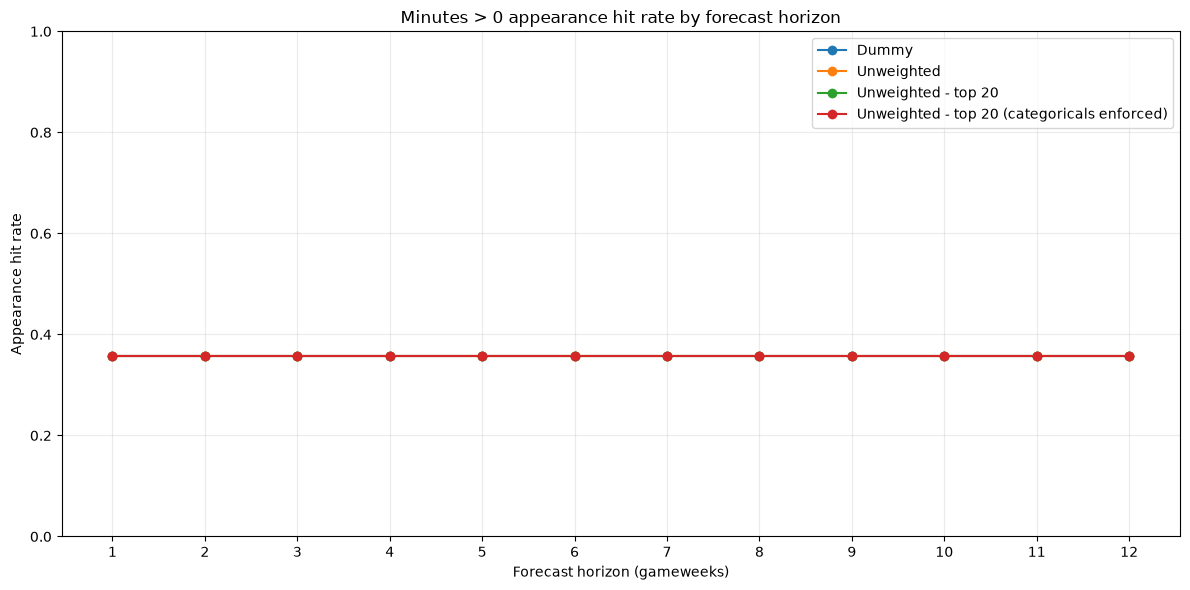

In [14]:
appearance_hit_rate_records = []
validation_context = fixture_history_with_horizons_df.loc[
    y_valid.index, ["season", "target_gw", "horizon"]
].reset_index(drop=True)

for model_name, predictions in validation_predictions.items():
    evaluation = validation_context.assign(
        actual=y_valid.to_numpy(),
        predicted=predictions,
    )
    for horizon, horizon_results in evaluation.groupby("horizon"):
        appearance_hit_rate_records.append({
            "model": model_name,
            "horizon": horizon,
            "appearance_hit_rate": horizon_results["predicted"].gt(0).eq(
                horizon_results["actual"].gt(0)
            ).mean(),
        })

appearance_hit_rate_by_horizon = (
    pd.DataFrame(appearance_hit_rate_records)
    .sort_values(["model", "horizon"])
)

figure, axis = plt.subplots(figsize=(12, 6))
for model_name, model_results in appearance_hit_rate_by_horizon.groupby("model"):
    axis.plot(
        model_results["horizon"],
        model_results["appearance_hit_rate"],
        marker="o",
        linewidth=1.5,
        label=model_name,
    )

axis.set(
    xlabel="Forecast horizon (gameweeks)",
    ylabel="Appearance hit rate",
    title="Minutes > 0 appearance hit rate by forecast horizon",
    xticks=range(1, MAX_HORIZON + 1),
    ylim=(0, 1),
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
axis

# Selected model
## Unweighted top 20 with categorical features enforced


In [15]:
selected_model = unweighted_enforced_model.copy()
selected_model_features = enforced_selected_features.copy()
selected_model_categorical_columns = CATEGORICAL_COLUMNS.copy()

## Selected-model SHAP values

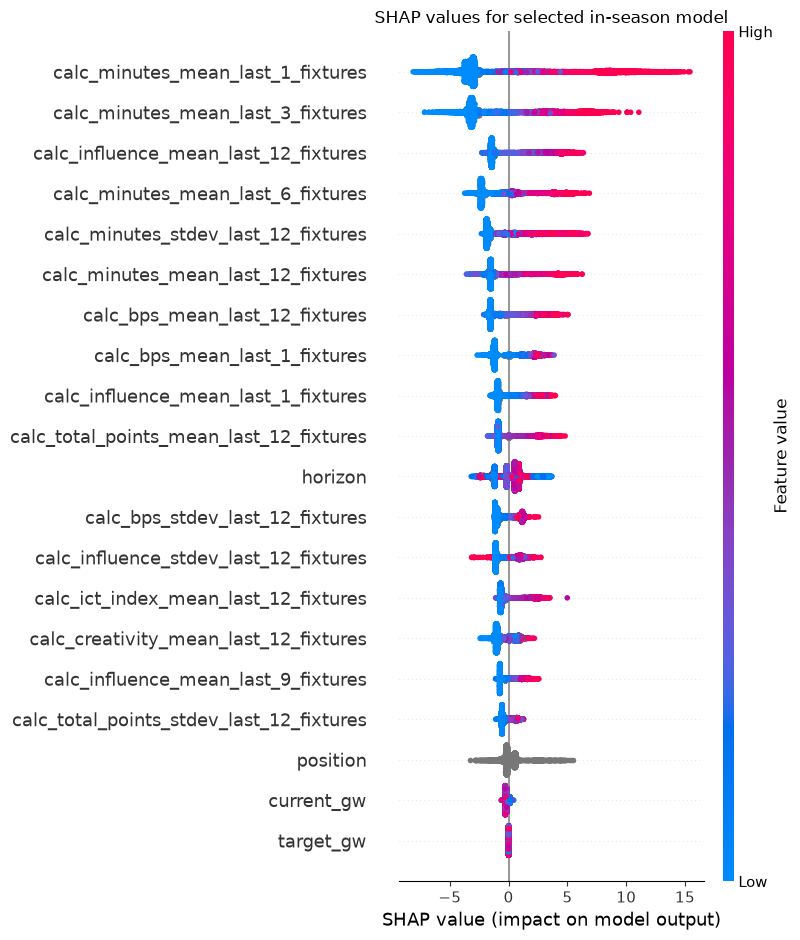

In [16]:
selected_shap_sample_df = X_valid[selected_model_features].sample(
    n=min(10_000, len(X_valid)),
    random_state=RANDOM_STATE,
)

selected_shap_explainer = shap.TreeExplainer(selected_model)
selected_shap_values = selected_shap_explainer(
    selected_shap_sample_df
)

shap.plots.beeswarm(
    selected_shap_values,
    max_display=len(selected_model_features),
    show=False,
)
plt.title("SHAP values for selected in-season model")
plt.tight_layout()
plt.show()

## Save

In [17]:
save_trained_catboost_model(
    model=selected_model,
    feature_columns=selected_model_features,
    categorical_columns=selected_model_categorical_columns,
    model_name="Unweighted CatBoost minutes model - top 20 features",
    model_version="0.1.0",
    save_path=MINUTES_ARTIFACT_PATH,
)
print(f"Saved minutes model to {MINUTES_ARTIFACT_PATH}")


Saved minutes model to /Users/calumthompson/Documents/fantasy_football_v2/src/prediction/artifacts/trained_models/minutes_model.joblib
